In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Load Data

In [7]:
# Path to combined results file
data_file = Path("/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_sweep/results_36nt/summaries/all_corrected_metrics.csv")

# Load data
if data_file.exists():
    df_all = pd.read_csv(data_file)
    print(f"Loaded data from: {data_file}")
    print(f"Total samples: {len(df_all)}")
    
    # Split by tool for individual analysis
    df_rb = df_all[df_all['tool'] == 'RandomBarcodes'].copy() if 'RandomBarcodes' in df_all['tool'].values else None
    df_quik = df_all[df_all['tool'] == 'QUIK'].copy() if 'QUIK' in df_all['tool'].values else None
    df_columba = df_all[df_all['tool'] == 'Columba'].copy() if 'Columba' in df_all['tool'].values else None
    
    print(f"RandomBarcodes samples: {len(df_rb) if df_rb is not None else 0}")
    print(f"QUIK samples: {len(df_quik) if df_quik is not None else 0}")
    print(f"Columba samples: {len(df_columba) if df_columba is not None else 0}")
else:
    print(f"ERROR: Data file not found: {data_file}")
    df_all = None
    df_rb = None
    df_quik = None
    df_columba = None

Loaded data from: /user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_sweep/results_36nt/summaries/all_corrected_metrics.csv
Total samples: 38
RandomBarcodes samples: 15
QUIK samples: 18
Columba samples: 5


In [8]:
# Preview data
if df_all is not None:
    display(df_all.head(10))

,tool,sample_id,identity_threshold,nthresh,ntriage,rejection_threshold,strategy,total_reads,correct,incorrect,unassigned,assignment_rate,precision,recall,accuracy,f1_score
0,RandomBarcodes,RB_t1000_n10,NaN,10.0,1000.0,NaN,NaN,200000,151911,414,47675,76.1625,99.728213,75.9555,75.9555,86.233449
1,RandomBarcodes,RB_t1000_n6,NaN,6.0,1000.0,NaN,NaN,200000,58837,1,141162,29.4190,99.998300,29.4185,29.4185,45.462413
2,RandomBarcodes,RB_t1000_n7,NaN,7.0,1000.0,NaN,NaN,200000,79899,2,120099,39.9505,99.997497,39.9495,39.9495,57.090900
3,RandomBarcodes,RB_t1000_n8,NaN,8.0,1000.0,NaN,NaN,200000,107652,8,92340,53.8300,99.992569,53.8260,53.8260,69.981148
4,RandomBarcodes,RB_t1000_n9,NaN,9.0,1000.0,NaN,NaN,200000,129286,69,70645,64.6775,99.946658,64.6430,64.6430,78.508600
5,RandomBarcodes,RB_t100_n10,NaN,10.0,100.0,NaN,NaN,200000,151616,375,48009,75.9955,99.753275,75.8080,75.8080,86.147657
6,RandomBarcodes,RB_t100_n6,NaN,6.0,100.0,NaN,NaN,200000,58837,1,141162,29.4190,99.998300,29.4185,29.4185,45.462413
7,RandomBarcodes,RB_t100_n7,NaN,7.0,100.0,NaN,NaN,200000,79899,2,120099,39.9505,99.997497,39.9495,39.9495,57.090900
8,RandomBarcodes,RB_t100_n8,NaN,8.0,100.0,NaN,NaN,200000,107642,8,92350,53.8250,99.992569,53.8210,53.8210,69.976922
9,RandomBarcodes,RB_t100_n9,NaN,9.0,100.0,NaN,NaN,200000,129227,65,70708,64.6460,99.949726,64.6135,64.6135,78.487786


In [12]:
# Fix logical operator for pandas boolean indexing (use & not "and", and wrap conditions in parentheses)
# rb_high_precision = df_all[(df_all["tool"] == "RandomBarcodes") & (df_all["precision"] > 99.9)]
# display(rb_high_precision)
tool = "QUIK"
recall_threshold = 20
precision_threshold = 99.9
df_all[(df_all['tool'] == tool) & (df_all['recall'] >= recall_threshold) & (df_all['precision'] >= precision_threshold)]


,tool,sample_id,identity_threshold,nthresh,ntriage,rejection_threshold,strategy,total_reads,correct,incorrect,unassigned,assignment_rate,precision,recall,accuracy,f1_score
16,QUIK,QUIK_47mer_r5,NaN,NaN,NaN,5.0,47mer,200000,114521,0,85479,57.2605,100.000000,57.2605,57.2605,72.822482
17,QUIK,QUIK_47mer_r6,NaN,NaN,NaN,6.0,47mer,200000,150651,1,49348,75.3260,99.999336,75.3255,75.3255,85.926217
18,QUIK,QUIK_47mer_r7,NaN,NaN,NaN,7.0,47mer,200000,174979,17,25004,87.4980,99.990285,87.4895,87.4895,93.323129
19,QUIK,QUIK_47mer_r8,NaN,NaN,NaN,8.0,47mer,200000,187234,108,12658,93.6710,99.942351,93.6170,93.6170,96.676322
22,QUIK,QUIK_4mer_r5,NaN,NaN,NaN,5.0,4mer,200000,114521,0,85479,57.2605,100.000000,57.2605,57.2605,72.822482
23,QUIK,QUIK_4mer_r6,NaN,NaN,NaN,6.0,4mer,200000,150653,1,49346,75.3270,99.999336,75.3265,75.3265,85.926868
24,QUIK,QUIK_4mer_r7,NaN,NaN,NaN,7.0,4mer,200000,174985,17,24998,87.5010,99.990286,87.4925,87.4925,93.324836
25,QUIK,QUIK_4mer_r8,NaN,NaN,NaN,8.0,4mer,200000,187253,108,12639,93.6805,99.942357,93.6265,93.6265,96.681390
28,QUIK,QUIK_77mer_r5,NaN,NaN,NaN,5.0,77mer,200000,114281,0,85719,57.1405,100.000000,57.1405,57.1405,72.725364
29,QUIK,QUIK_77mer_r6,NaN,NaN,NaN,6.0,77mer,200000,148954,1,51045,74.4775,99.999329,74.4770,74.4770,85.371466


## 2. Summary Statistics

In [4]:
# Summary by tool
if df_all is not None:
    summary = df_all.groupby('tool')[['precision', 'recall', 'f1_score', 'assignment_rate']].agg(['mean', 'std', 'min', 'max'])
    print("\n=== Summary Statistics by Tool ===")
    display(summary)


=== Summary Statistics by Tool ===


precision                                    recall  \
                     mean       std        min       max       mean   
tool                                                                  
Columba         95.584400  4.204645  88.150700   97.9007  55.134600   
QUIK            99.625309  0.682455  97.733938  100.0000  83.494361   
RandomBarcodes  99.934298  0.104804  99.725610   99.9983  52.746767   

                                             f1_score                        \
                      std      min     max       mean        std        min   
tool                                                                          
Columba         17.908572  31.7605  75.911  68.220240  14.149465  47.929346   
QUIK            14.044852  57.1405  96.406  90.170282   8.957744  72.725364   
RandomBarcodes  17.239144  29.4185  75.960  67.448100  15.149827  45.462413   

                          assignment_rate                               
                      max            mean        std      min      max  
tool                                                                    
Columba         81.574283       58.274600  21.112329  32.5305  86.1150  
QUIK            97.719513       83.853917  14.355563  57.1405  97.9265  
RandomBarcodes  86.235376       52.794900  17.301915  29.4190  76.1690

In [5]:
# Best configurations for each tool
if df_all is not None:
    print("\n=== Best Configuration by Tool (based on F1-score) ===")
    for tool in df_all['tool'].unique():
        tool_data = df_all[df_all['tool'] == tool]
        best = tool_data.loc[tool_data['f1_score'].idxmax()]
        print(f"\n{tool}:")
        print(f"  Sample: {best['sample_id']}")
        print(f"  Precision: {best['precision']:.2f}%")
        print(f"  Recall: {best['recall']:.2f}%")
        print(f"  F1-Score: {best['f1_score']:.2f}")
        print(f"  Assignment Rate: {best['assignment_rate']:.2f}%")


=== Best Configuration by Tool (based on F1-score) ===

RandomBarcodes:
  Sample: RB_t5000_n10
  Precision: 99.73%
  Recall: 75.96%
  F1-Score: 86.24
  Assignment Rate: 76.17%

QUIK:
  Sample: QUIK_4mer_r9
  Precision: 99.63%
  Recall: 95.88%
  F1-Score: 97.72
  Assignment Rate: 96.23%

Columba:
  Sample: Columba36_I72
  Precision: 88.15%
  Recall: 75.91%
  F1-Score: 81.57
  Assignment Rate: 86.11%


## 3. Overall Tool Comparison

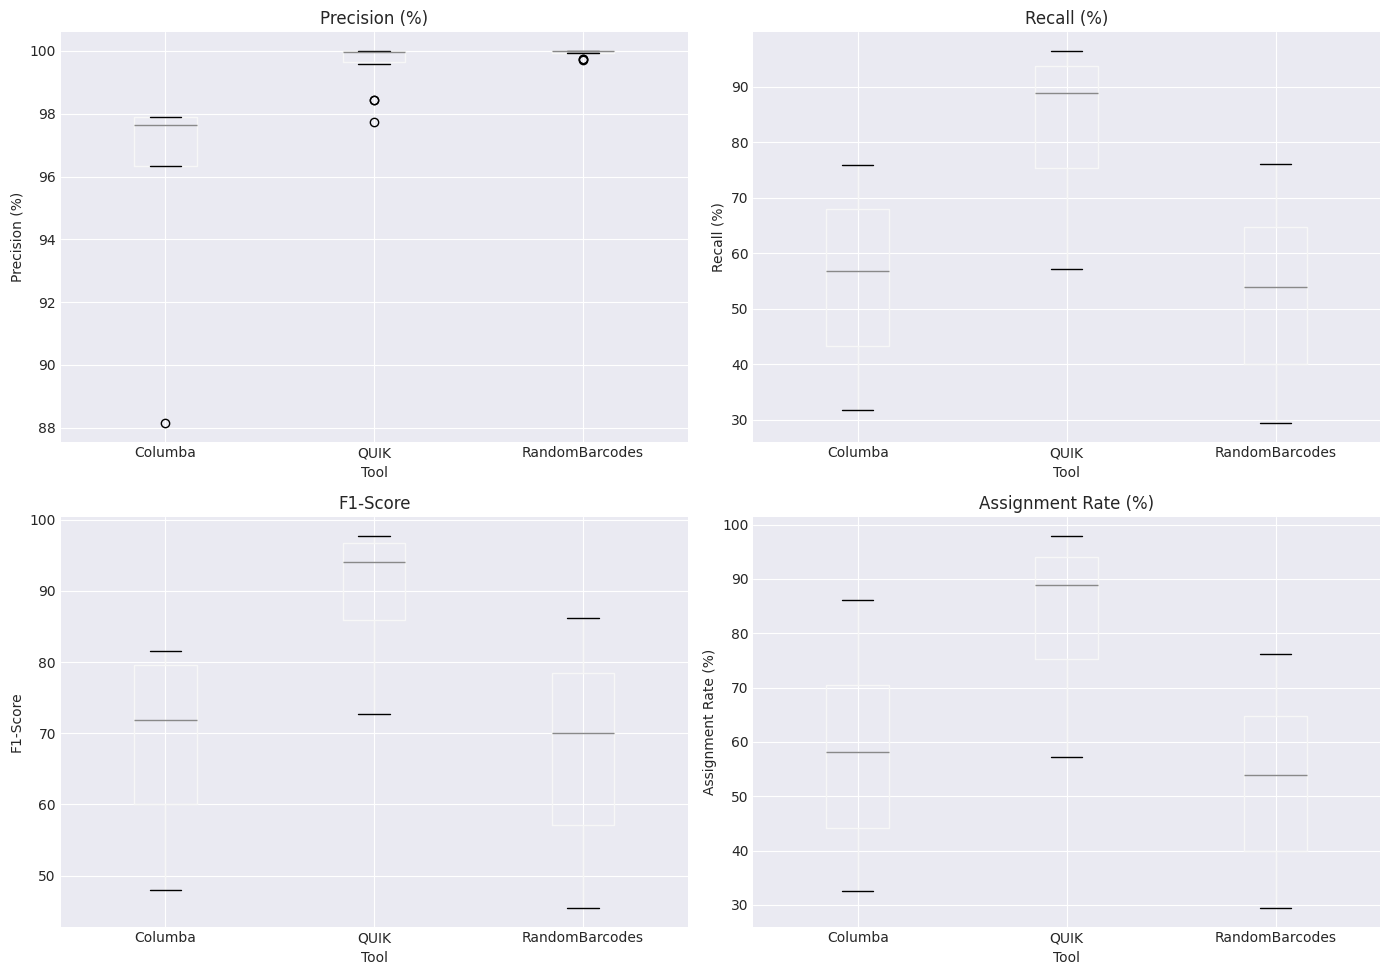

In [6]:
# Box plots comparing tools
if df_all is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = ['precision', 'recall', 'f1_score', 'assignment_rate']
    titles = ['Precision (%)', 'Recall (%)', 'F1-Score', 'Assignment Rate (%)']
    
    for ax, metric, title in zip(axes.flat, metrics, titles):
        df_all.boxplot(column=metric, by='tool', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Tool')
        ax.set_ylabel(title)
        ax.get_figure().suptitle('')
    
    plt.tight_layout()
    plt.savefig('figures_36nt/tool_comparison_boxplots.pdf', dpi=300, bbox_inches='tight')
    plt.show()

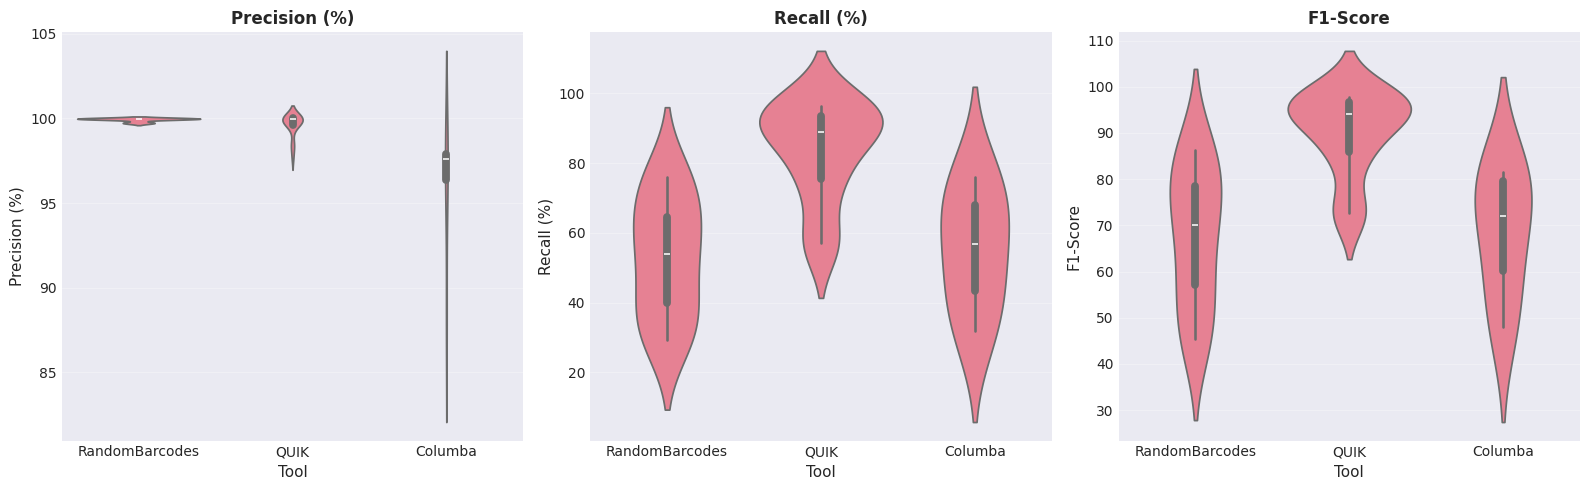

In [7]:
# Violin plots for better distribution visualization
if df_all is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, metric, title in zip(axes, ['precision', 'recall', 'f1_score'], 
                                  ['Precision (%)', 'Recall (%)', 'F1-Score']):
        sns.violinplot(data=df_all, x='tool', y=metric, ax=ax)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Tool', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures_36nt/tool_comparison_violins.pdf', dpi=300, bbox_inches='tight')
    plt.show()

## 4. RandomBarcodes Parameter Analysis

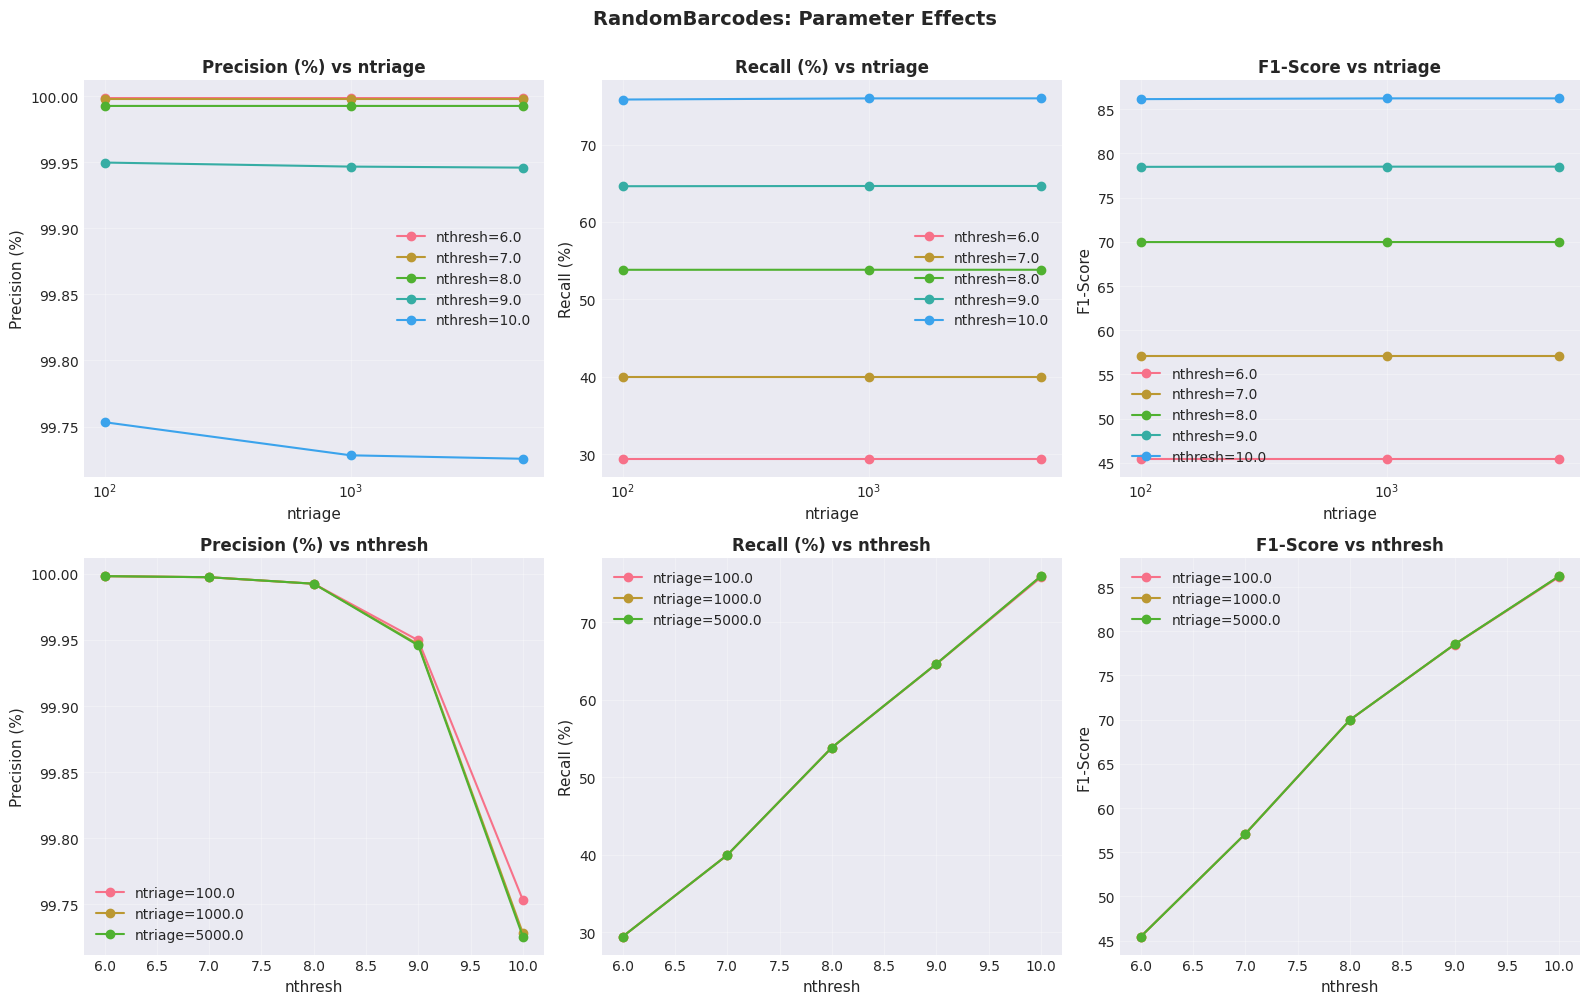

In [8]:
# RandomBarcodes: Effect of ntriage and nthresh
if df_rb is not None:
    # Convert to numeric
    df_rb['ntriage'] = pd.to_numeric(df_rb['ntriage'])
    df_rb['nthresh'] = pd.to_numeric(df_rb['nthresh'])
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    metrics = ['precision', 'recall', 'f1_score']
    titles = ['Precision (%)', 'Recall (%)', 'F1-Score']
    
    # Plot by ntriage
    for ax, metric, title in zip(axes[0], metrics, titles):
        for nthresh in sorted(df_rb['nthresh'].unique()):
            data = df_rb[df_rb['nthresh'] == nthresh].sort_values('ntriage')
            ax.plot(data['ntriage'], data[metric], marker='o', label=f'nthresh={nthresh}')
        ax.set_xlabel('ntriage', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs ntriage', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.set_xscale('log')
    
    # Plot by nthresh
    for ax, metric, title in zip(axes[1], metrics, titles):
        for ntriage in sorted(df_rb['ntriage'].unique()):
            data = df_rb[df_rb['ntriage'] == ntriage].sort_values('nthresh')
            ax.plot(data['nthresh'], data[metric], marker='o', label=f'ntriage={ntriage}')
        ax.set_xlabel('nthresh', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs nthresh', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.suptitle('RandomBarcodes: Parameter Effects', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figures_36nt/randombarcodes_parameters.pdf', dpi=300, bbox_inches='tight')
    plt.show()

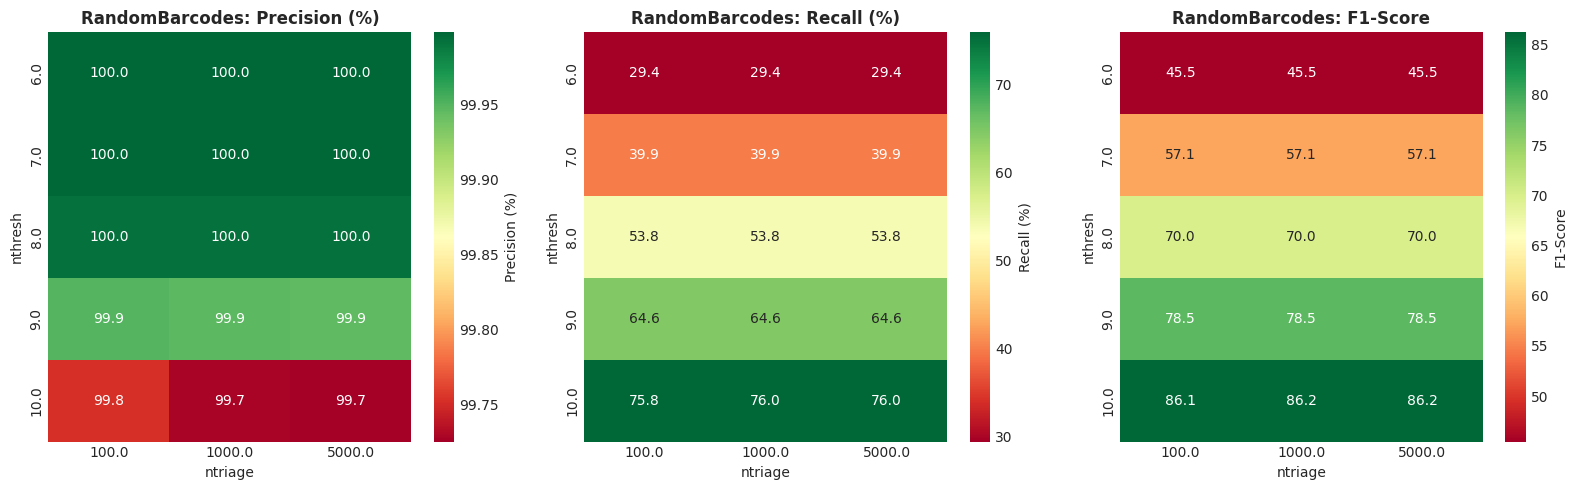

In [9]:
# RandomBarcodes: Heatmaps
if df_rb is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, metric, title in zip(axes, ['precision', 'recall', 'f1_score'],
                                  ['Precision (%)', 'Recall (%)', 'F1-Score']):
        pivot = df_rb.pivot(index='nthresh', columns='ntriage', values=metric)
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, cbar_kws={'label': title})
        ax.set_title(f'RandomBarcodes: {title}', fontweight='bold')
        ax.set_xlabel('ntriage')
        ax.set_ylabel('nthresh')
    
    plt.tight_layout()
    plt.savefig('figures_36nt/randombarcodes_heatmaps.pdf', dpi=300, bbox_inches='tight')
    plt.show()

## 5. QUIK Parameter Analysis

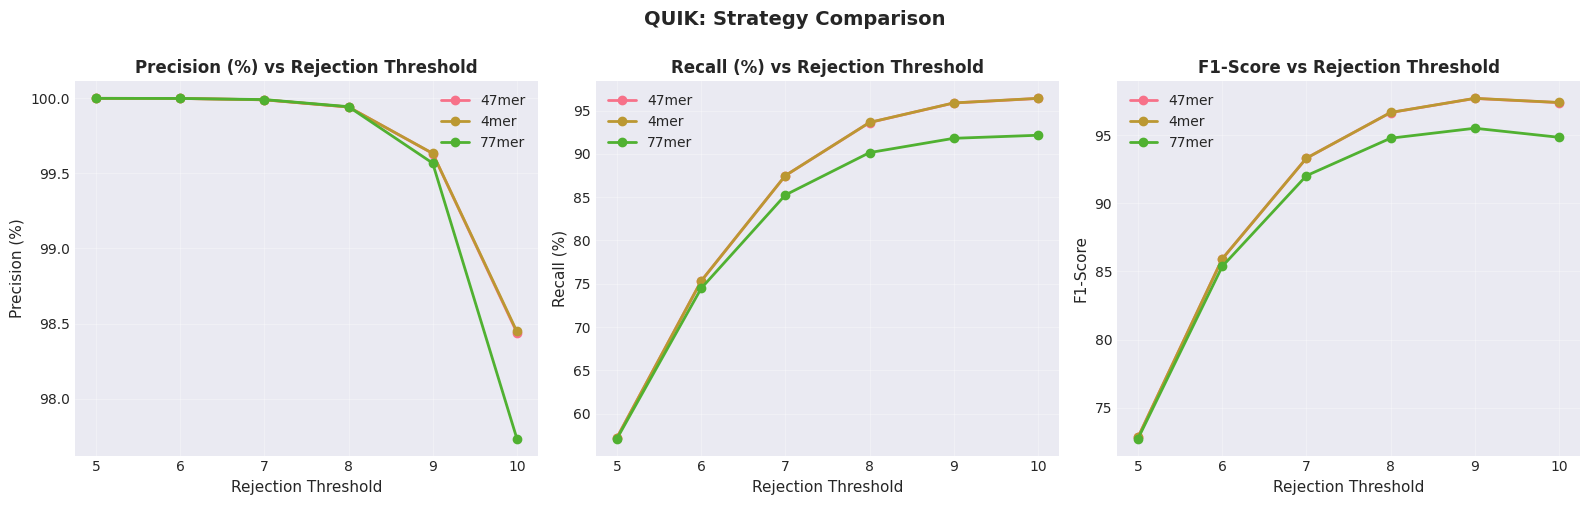

In [10]:
# QUIK: Effect of strategy and rejection_threshold
if df_quik is not None:
    df_quik['rejection_threshold'] = pd.to_numeric(df_quik['rejection_threshold'])
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['precision', 'recall', 'f1_score']
    titles = ['Precision (%)', 'Recall (%)', 'F1-Score']
    
    for ax, metric, title in zip(axes, metrics, titles):
        for strategy in sorted(df_quik['strategy'].unique()):
            data = df_quik[df_quik['strategy'] == strategy].sort_values('rejection_threshold')
            ax.plot(data['rejection_threshold'], data[metric], marker='o', label=strategy, linewidth=2)
        ax.set_xlabel('Rejection Threshold', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs Rejection Threshold', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.suptitle('QUIK: Strategy Comparison', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figures_36nt/quik_parameters.pdf', dpi=300, bbox_inches='tight')
    plt.show()

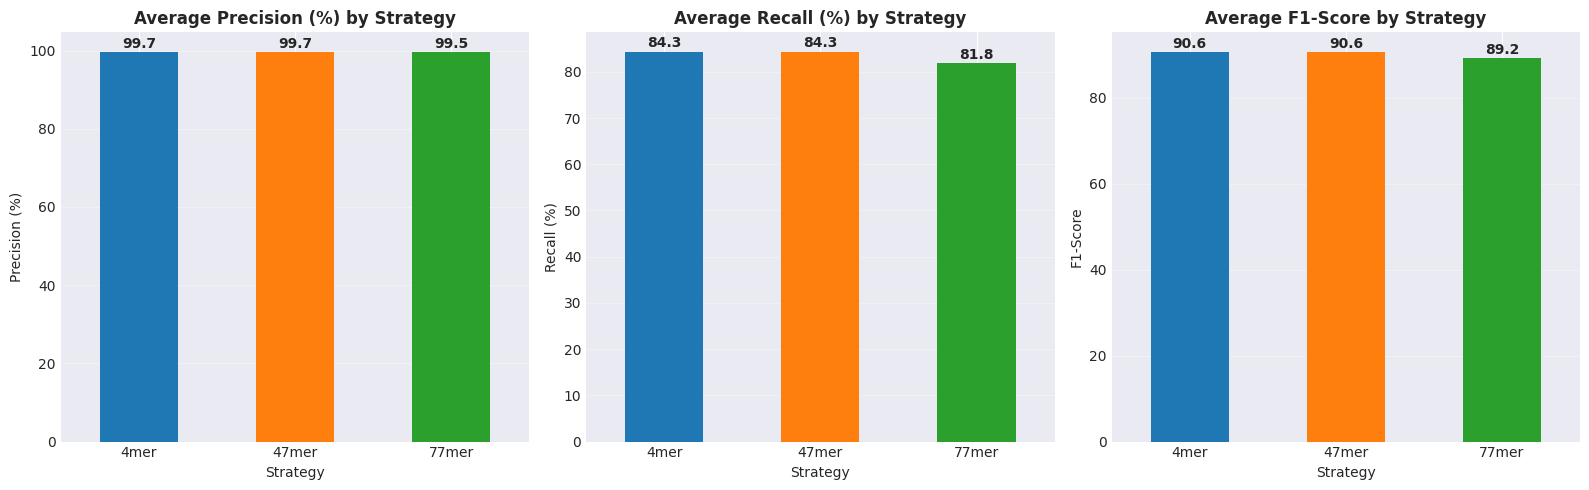

In [11]:
# QUIK: Bar plot comparison by strategy
if df_quik is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, metric, title in zip(axes, ['precision', 'recall', 'f1_score'],
                                  ['Precision (%)', 'Recall (%)', 'F1-Score']):
        strategy_avg = df_quik.groupby('strategy')[metric].mean().sort_values(ascending=False)
        strategy_avg.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax.set_title(f'Average {title} by Strategy', fontweight='bold')
        ax.set_xlabel('Strategy')
        ax.set_ylabel(title)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(strategy_avg.values):
            ax.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures_36nt/quik_strategy_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()

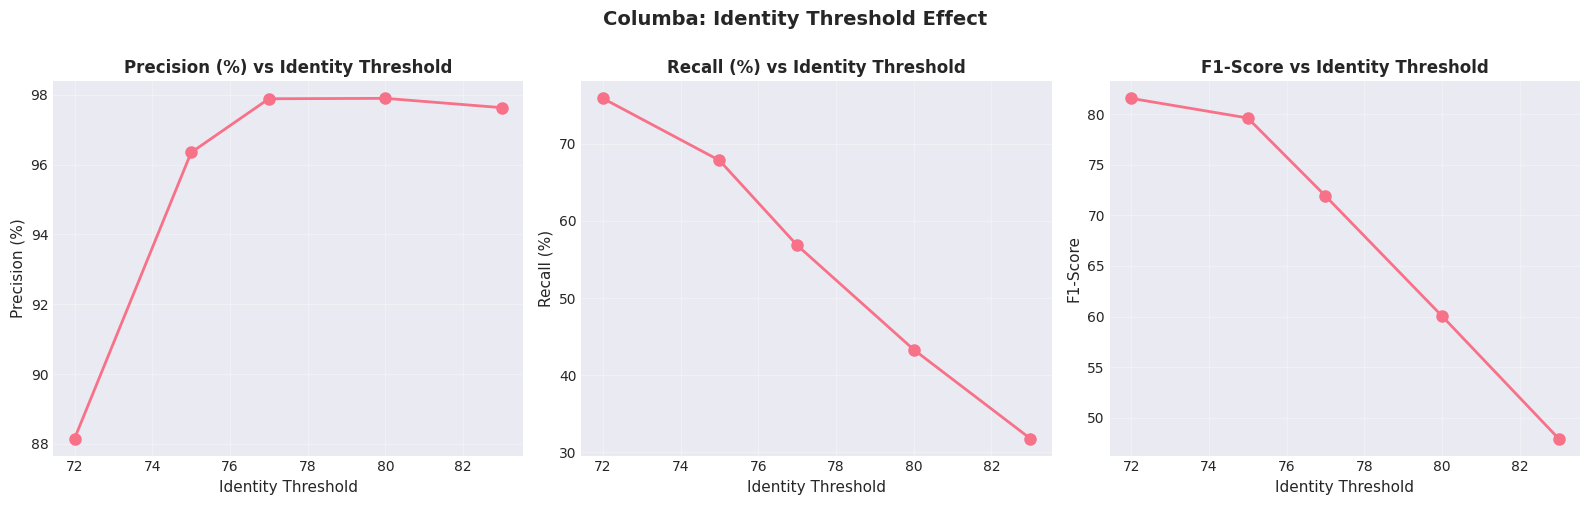

In [12]:
# Columba: Effect of identity_threshold
if df_columba is not None:
    df_columba['identity_threshold'] = pd.to_numeric(df_columba['identity_threshold'])
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['precision', 'recall', 'f1_score']
    titles = ['Precision (%)', 'Recall (%)', 'F1-Score']
    
    for ax, metric, title in zip(axes, metrics, titles):
        data = df_columba.sort_values('identity_threshold')
        ax.plot(data['identity_threshold'], data[metric], marker='o', linewidth=2, markersize=8)
        ax.set_xlabel('Identity Threshold', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs Identity Threshold', fontweight='bold')
        ax.grid(alpha=0.3)
    
    plt.suptitle('Columba: Identity Threshold Effect', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figures_36nt/columba_parameters.pdf', dpi=300, bbox_inches='tight')
    plt.show()

## 6. Columba Parameter Analysis

## 6. Precision-Recall Trade-off

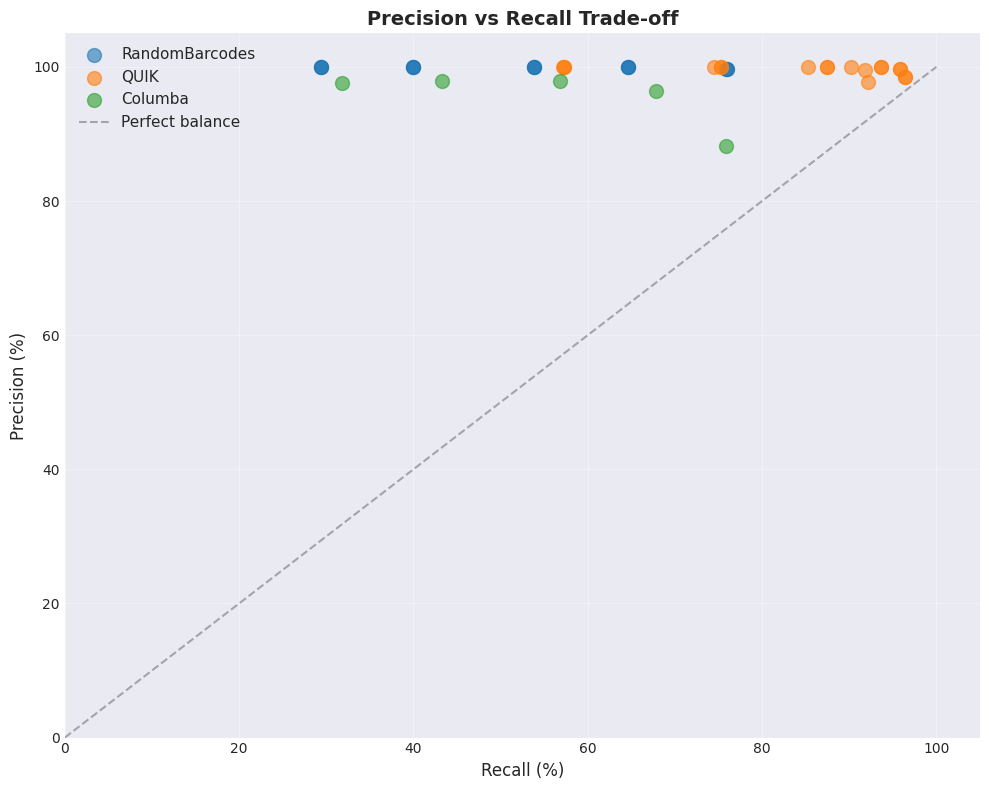

In [13]:
# Precision vs Recall scatter plot
if df_all is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = {'RandomBarcodes': '#1f77b4', 'QUIK': '#ff7f0e', 'Columba': '#2ca02c'}
    
    for tool in df_all['tool'].unique():
        data = df_all[df_all['tool'] == tool]
        ax.scatter(data['recall'], data['precision'], 
                  label=tool, alpha=0.6, s=100, color=colors.get(tool, 'gray'))
    
    # Add diagonal line (perfect precision-recall)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect balance')
    
    ax.set_xlabel('Recall (%)', fontsize=12)
    ax.set_ylabel('Precision (%)', fontsize=12)
    ax.set_title('Precision vs Recall Trade-off', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 105)
    ax.set_ylim(0, 105)
    
    plt.tight_layout()
    plt.savefig('figures_36nt/precision_recall_tradeoff.pdf', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Assignment Rate Analysis

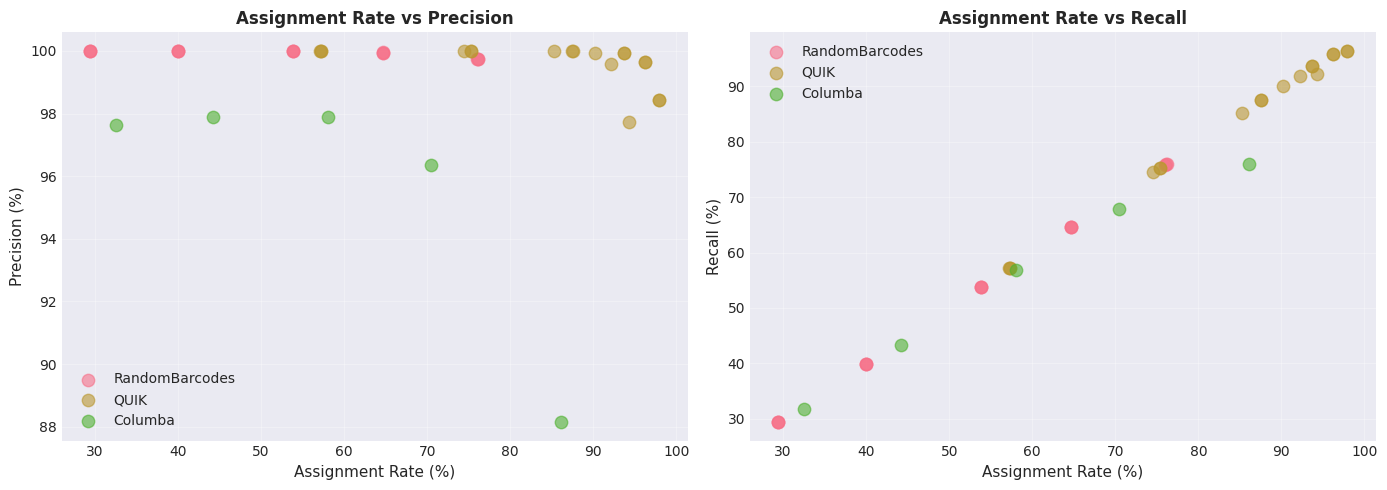

In [14]:
# Assignment rate vs metrics
if df_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for tool in df_all['tool'].unique():
        data = df_all[df_all['tool'] == tool]
        axes[0].scatter(data['assignment_rate'], data['precision'], 
                       label=tool, alpha=0.6, s=80)
        axes[1].scatter(data['assignment_rate'], data['recall'], 
                       label=tool, alpha=0.6, s=80)
    
    axes[0].set_xlabel('Assignment Rate (%)', fontsize=11)
    axes[0].set_ylabel('Precision (%)', fontsize=11)
    axes[0].set_title('Assignment Rate vs Precision', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].set_xlabel('Assignment Rate (%)', fontsize=11)
    axes[1].set_ylabel('Recall (%)', fontsize=11)
    axes[1].set_title('Assignment Rate vs Recall', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures_36nt/assignment_rate_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Top Performing Configurations


=== Top 10 Configurations (by F1-score) ===


,tool,sample_id,precision,recall,f1_score,assignment_rate
26,QUIK,QUIK_4mer_r9,99.633690,95.8775,97.719513,96.2300
20,QUIK,QUIK_47mer_r9,99.632615,95.8670,97.713542,96.2205
21,QUIK,QUIK_4mer_r10,98.447305,96.4060,97.415960,97.9265
15,QUIK,QUIK_47mer_r10,98.440085,96.3945,97.406554,97.9220
25,QUIK,QUIK_4mer_r8,99.942357,93.6265,96.681390,93.6805
19,QUIK,QUIK_47mer_r8,99.942351,93.6170,96.676322,93.6710
32,QUIK,QUIK_77mer_r9,99.568292,91.7940,95.523227,92.1920
27,QUIK,QUIK_77mer_r10,97.733938,92.1460,94.857746,94.2825
31,QUIK,QUIK_77mer_r8,99.944564,90.1440,94.791634,90.1940
24,QUIK,QUIK_4mer_r7,99.990286,87.4925,93.324836,87.5010


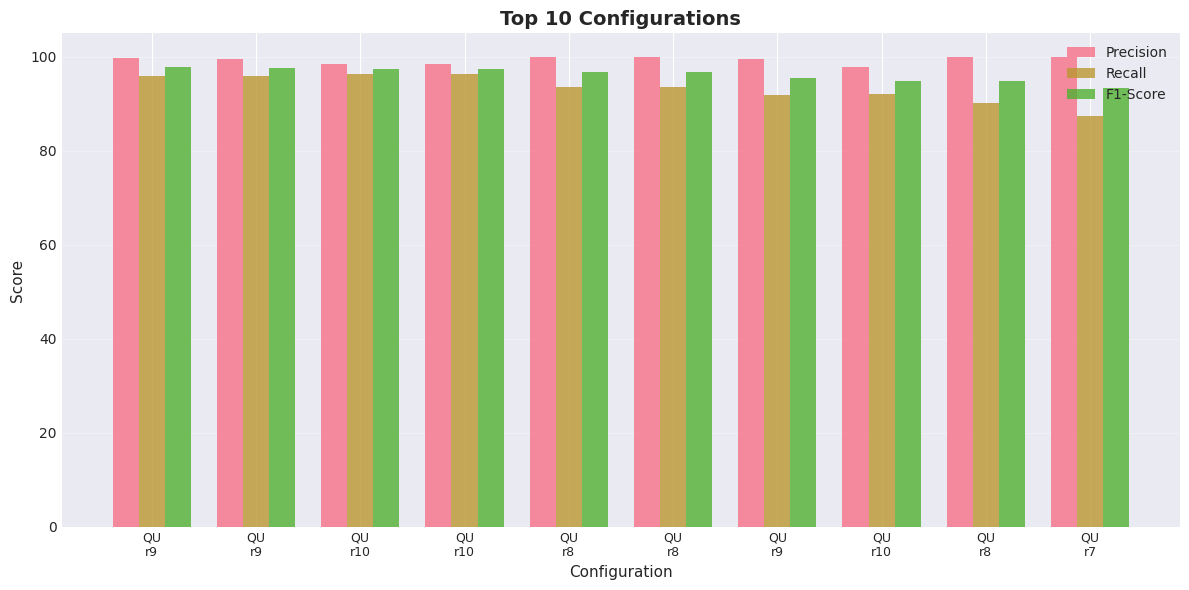

In [15]:
# Top 10 configurations by F1-score
if df_all is not None:
    print("\n=== Top 10 Configurations (by F1-score) ===")
    top10 = df_all.nlargest(10, 'f1_score')[['tool', 'sample_id', 'precision', 'recall', 'f1_score', 'assignment_rate']]
    display(top10)
    
    # Visualize top 10
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(top10))
    width = 0.25
    
    ax.bar([i - width for i in x], top10['precision'], width, label='Precision', alpha=0.8)
    ax.bar(x, top10['recall'], width, label='Recall', alpha=0.8)
    ax.bar([i + width for i in x], top10['f1_score'], width, label='F1-Score', alpha=0.8)
    
    ax.set_xlabel('Configuration', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Top 10 Configurations', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{row['tool'][:2]}\n{row['sample_id'].split('_')[-1]}" 
                        for _, row in top10.iterrows()], rotation=0, fontsize=9)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures_36nt/top10_configurations.pdf', dpi=300, bbox_inches='tight')
    plt.show()

## 9. Export Summary Report

In [16]:
# Create summary report
if df_all is not None:
    report = []
    report.append("="*80)
    report.append("PARAMETER SWEEP ANALYSIS SUMMARY - 28nt Barcodes")
    report.append("="*80)
    report.append("")
    report.append(f"Dataset: 21,000 barcodes (28nt), 200,000 simulated reads")
    report.append(f"Total configurations tested: {len(df_all)}")
    report.append("")
    
    report.append("-"*80)
    report.append("OVERALL PERFORMANCE BY TOOL")
    report.append("-"*80)
    for tool in df_all['tool'].unique():
        tool_data = df_all[df_all['tool'] == tool]
        report.append(f"\n{tool}:")
        report.append(f"  Configurations: {len(tool_data)}")
        report.append(f"  Avg Precision:  {tool_data['precision'].mean():.2f}% (±{tool_data['precision'].std():.2f})")
        report.append(f"  Avg Recall:     {tool_data['recall'].mean():.2f}% (±{tool_data['recall'].std():.2f})")
        report.append(f"  Avg F1-Score:   {tool_data['f1_score'].mean():.2f} (±{tool_data['f1_score'].std():.2f})")
        report.append(f"  Avg Assign Rate: {tool_data['assignment_rate'].mean():.2f}%")
    
    report.append("")
    report.append("-"*80)
    report.append("BEST CONFIGURATION PER TOOL (by F1-score)")
    report.append("-"*80)
    for tool in df_all['tool'].unique():
        tool_data = df_all[df_all['tool'] == tool]
        best = tool_data.loc[tool_data['f1_score'].idxmax()]
        report.append(f"\n{tool}: {best['sample_id']}")
        report.append(f"  Precision:  {best['precision']:.2f}%")
        report.append(f"  Recall:     {best['recall']:.2f}%")
        report.append(f"  F1-Score:   {best['f1_score']:.2f}")
        report.append(f"  Assign Rate: {best['assignment_rate']:.2f}%")
    
    report.append("")
    report.append("="*80)
    
    # Print report
    report_text = "\n".join(report)
    print(report_text)
    
    # Save report
    with open('summary_report_36nt.txt', 'w') as f:
        f.write(report_text)
    
    print("\n✓ Summary report saved to: summary_report.txt")

PARAMETER SWEEP ANALYSIS SUMMARY - 28nt Barcodes

Dataset: 21,000 barcodes (28nt), 200,000 simulated reads
Total configurations tested: 38

--------------------------------------------------------------------------------
OVERALL PERFORMANCE BY TOOL
--------------------------------------------------------------------------------

RandomBarcodes:
  Configurations: 15
  Avg Precision:  99.93% (±0.10)
  Avg Recall:     52.75% (±17.24)
  Avg F1-Score:   67.45 (±15.15)
  Avg Assign Rate: 52.79%

QUIK:
  Configurations: 18
  Avg Precision:  99.63% (±0.68)
  Avg Recall:     83.49% (±14.04)
  Avg F1-Score:   90.17 (±8.96)
  Avg Assign Rate: 83.85%

Columba:
  Configurations: 5
  Avg Precision:  95.58% (±4.20)
  Avg Recall:     55.13% (±17.91)
  Avg F1-Score:   68.22 (±14.15)
  Avg Assign Rate: 58.27%

--------------------------------------------------------------------------------
BEST CONFIGURATION PER TOOL (by F1-score)
-------------------------------------------------------------------------